In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("/content/customer_segmentation.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [6]:
df.shape

(2240, 29)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [9]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [21]:
df = df.dropna().copy()
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [22]:
df.isna().sum().sum()

np.int64(0)

In [23]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,2013-07-10 11:29:27.509025280,49.012635,305.091606,26.356047,166.995939,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,24.000000,2.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,174.500000,8.000000,68.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-31 00:00:00,74.000000,505.000000,33.000000,232.250000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,NaN,28.948352,337.327920,39.793917,224.283273,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417


In [24]:
df['Education'].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [25]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [26]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],dayfirst = True)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [29]:
df['Age'] = 2026 - df['Year_Birth']

In [30]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,45


In [31]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [33]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children'],
      dtype='object')

In [37]:
spend_cols=['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']

In [38]:
df['Total_spending']=df[spend_cols].sum(axis =1)

In [39]:
df['Total_spending'].head()

,Total_spending
0,1617
1,27
2,776
3,53
4,422


In [40]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spend,Total_spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,3,11,1,69,0,1617,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,3,11,0,72,2,27,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,3,11,0,61,0,776,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,3,11,0,42,1,53,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,3,11,0,45,1,422,422


In [61]:
df=df.drop(columns=['Total_Spend'],axis=1)

In [62]:
df['Customer_Since']= (pd.Timestamp('today')-df['Dt_Customer']).dt.days

In [63]:
df['Customer_Since']

,Customer_Since
0,5098
1,4548
2,4747
3,4574
4,4596
...,...
2235,4816
2236,4454
2237,4590
2238,4591


In [64]:
df.drop(columns=['Custromer_Since'], inplace=True, errors='ignore')

Text(0.5, 1.0, 'Age Distribution')

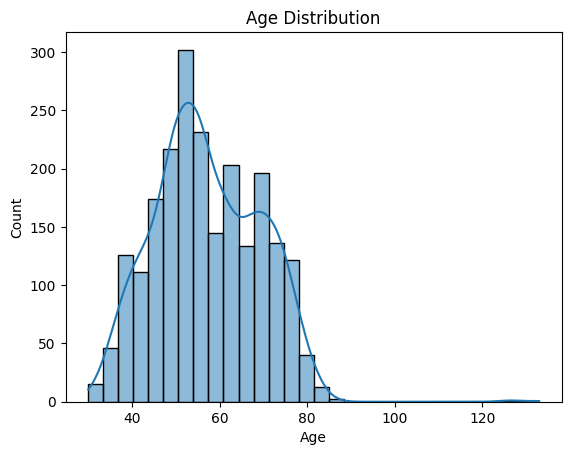

In [65]:
sns.histplot(df['Age'],bins=30,kde=True)
plt.title("Age Distribution")


Text(0.5, 1.0, 'Income Distribution')

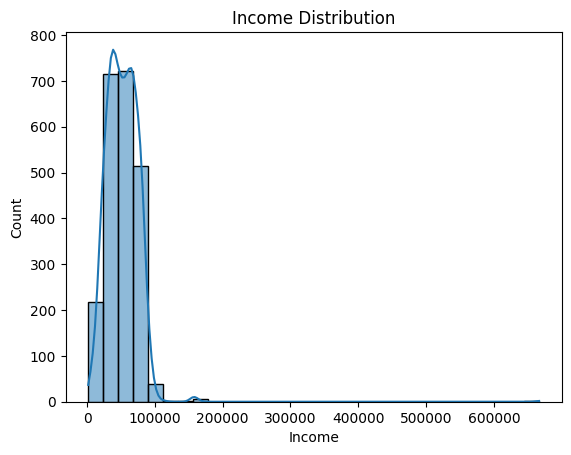

In [66]:
sns.histplot(df['Income'],bins=30,kde=True)
plt.title("Income Distribution")

Text(0.5, 1.0, 'Total Spending Distribution')

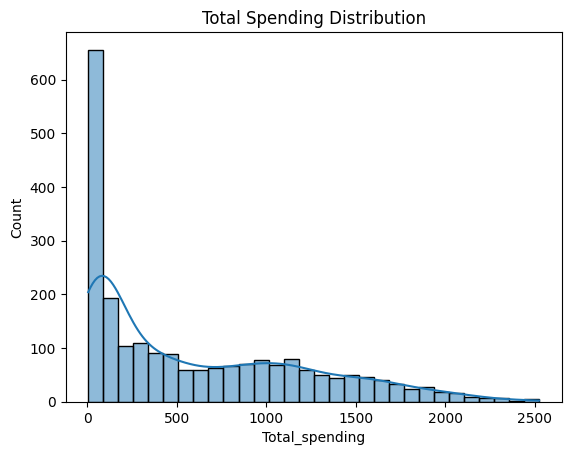

In [67]:
sns.histplot(df['Total_spending'],bins=30,kde=True)
plt.title("Total Spending Distribution")

Text(0.5, 1.0, 'Education vs Income')

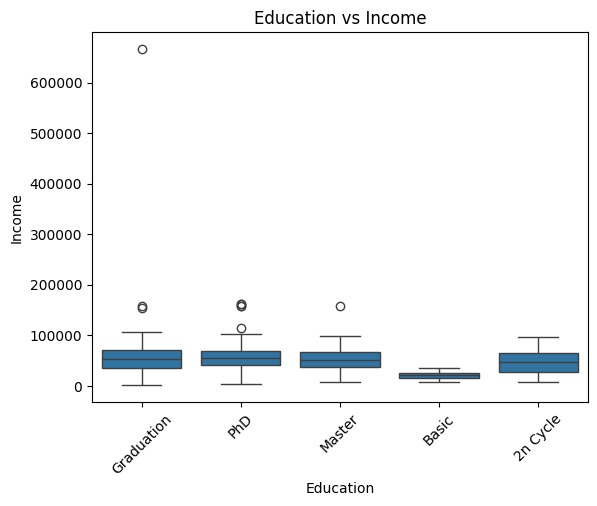

In [68]:
sns.boxplot(x='Education',y='Income',data = df)
plt.xticks(rotation=45)
plt.title("Education vs Income")

Text(0.5, 1.0, 'Marital Status vs Total Spending')

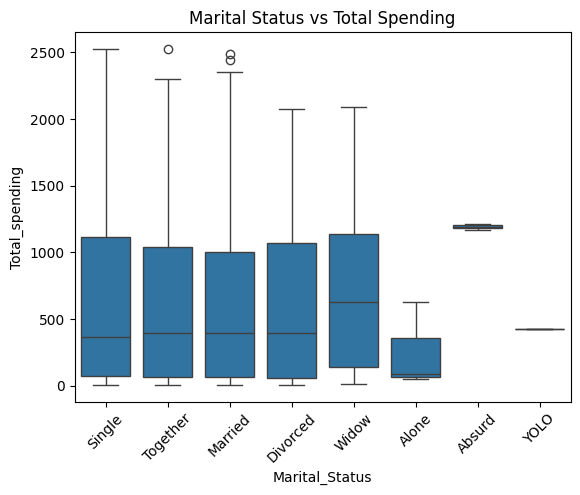

In [69]:
sns.boxplot(x='Marital_Status',y='Total_spending',data = df)
plt.xticks(rotation=45)
plt.title("Marital Status vs Total Spending")

In [70]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_spending', 'Customer_Since'],
      dtype='object')

In [76]:
corr = df[[ 'Income','Age','Recency','Total_spending','NumWebPurchases','NumStorePurchases']].corr()

In [77]:
corr

,Income,Age,Recency,Total_spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

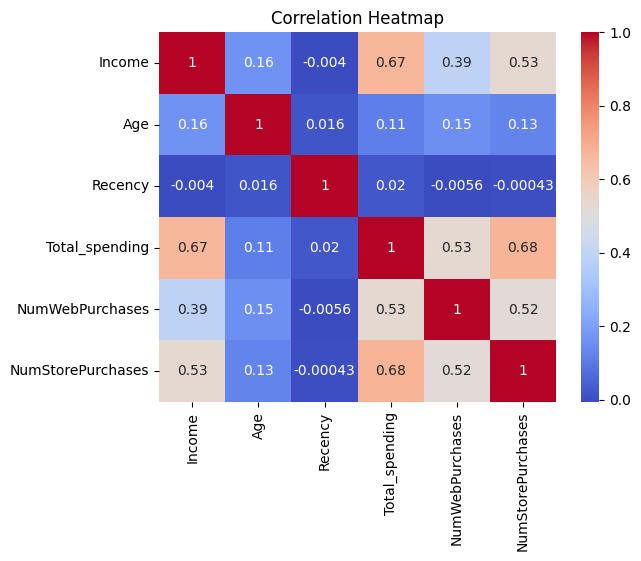

In [78]:
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")

In [83]:
pivot_income = df.pivot_table(values='Income', index='Education', columns='Marital_Status', aggfunc="mean")

In [86]:
pivot_income


Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


Text(0.5, 1.0, 'Average Income by Education and Marital Status')

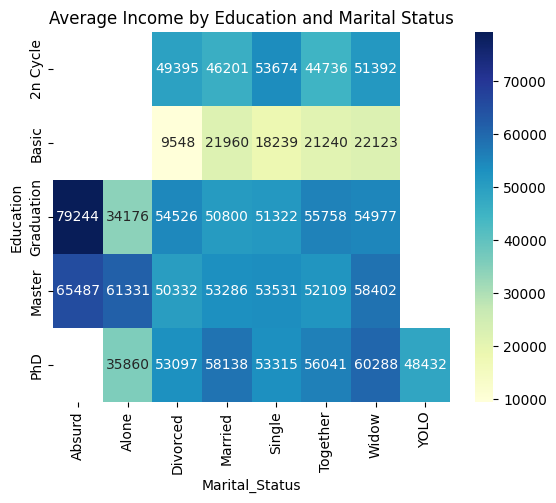

In [89]:
sns.heatmap(pivot_income, annot = True, fmt = ".0f",cmap = "YlGnBu")
plt.title("Average Income by Education and Marital Status")

In [90]:
group1= df.groupby('Education')['Total_spending'].mean().sort_values(ascending = False)

<Axes: xlabel='Education'>

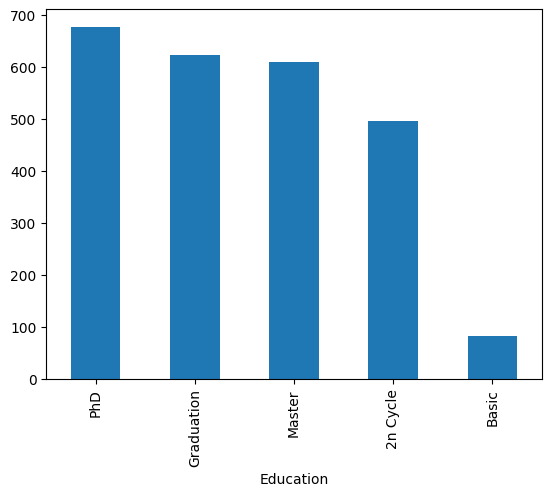

In [91]:
group1.plot(kind = "bar")

In [95]:
df['AcceptedAny'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis=1)

In [97]:
df['AcceptedAny'] = df['AcceptedAny'].apply(lambda x :1 if x>0 else 0 )

In [98]:
group2 = df.groupby('Marital_Status')['AcceptedAny'].mean().sort_values(ascending = False)

In [99]:
group2

,AcceptedAny
Marital_Status,
Absurd,0.500000
YOLO,0.500000
Widow,0.342105
Alone,0.333333
Single,0.312102
Divorced,0.297414
Married,0.252042
Together,0.251309


Text(0.5, 1.0, 'Campaaign Acceptance Rate by Marital Status ')

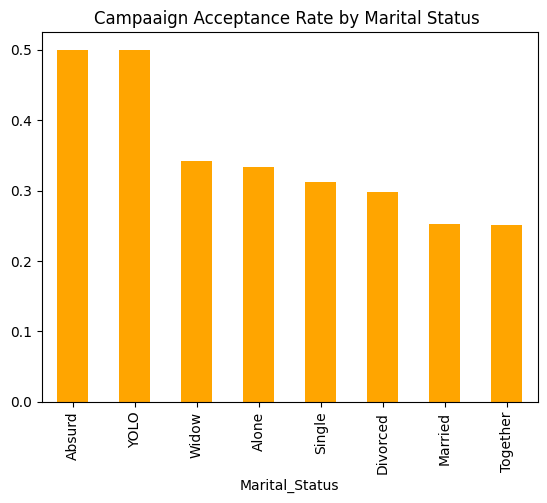

In [100]:
group2.plot(kind='bar',color = 'orange')
plt.title("Campaaign Acceptance Rate by Marital Status ")

In [101]:
bins = [18,30,40,50,60,70,90]

In [103]:
labels = ["18-29","30-39","40-49","50-59","60-69","70+"]

In [104]:
df['AgeGroup']= pd.cut(df['Age'], bins = bins , labels = labels)

In [105]:
group3 = df.groupby('AgeGroup')['Income'].mean()

/tmp/ipykernel_1737/3061263347.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby('AgeGroup')['Income'].mean()


In [106]:
group3

,Income
AgeGroup,
18-29,10960.500000
30-39,47905.475676
40-49,48057.587649
50-59,50479.321534
60-69,55980.030928
70+,58767.083102


Text(0.5, 1.0, 'average income by the age group ')

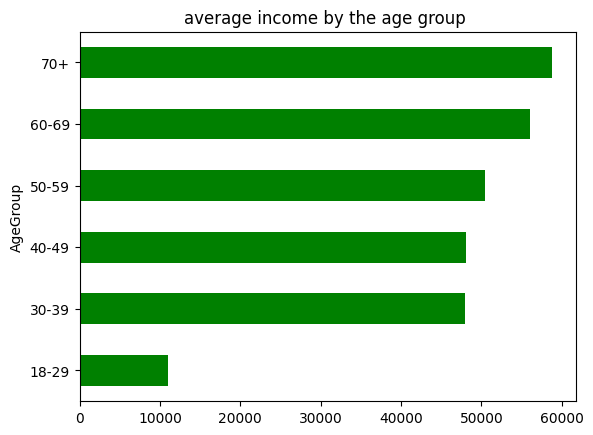

In [107]:
group3.plot(kind="barh", color = 'green')
plt.title("average income by the age group ")

In [108]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_spending,Customer_Since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,69,0,1617,5098,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,72,2,27,4548,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,61,0,776,4747,0,60-69
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,42,1,53,4574,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,45,1,422,4596,0,40-49


In [109]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [116]:
features = ['Age','Income','Total_spending','NumWebPurchases','NumStorePurchases','NumWebVisitsMonth','Recency']

In [117]:
X = df[features].copy()

In [118]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [119]:
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]])

In [136]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled) # Use your scaled data variable name here
    wcss.append(kmeans.inertia_)

In [131]:
wcss

[10218.620143748776,
 9007.786818672812,
 8159.308807446066,
 7567.674523392856,
 7094.35878877465,
 6643.722009513365,
 6620.918191965837,
 5860.632197255102,
 10218.620143748776,
 9007.786818672812,
 8159.608710191204,
 7568.096515141528,
 7205.763179036381,
 6711.414595628106,
 6553.694209260813,
 6278.329849271973,
 15511.999999999995,
 10218.648106906185,
 9007.783808892209,
 8159.181808713771,
 7642.666029832161,
 7265.49141072884,
 6734.079073380261,
 6200.637196504249,
 6219.761846212425,
 15511.999999999995,
 10218.620143748776,
 9007.786818672812,
 8158.852950223186,
 7635.762678210103,
 7133.443949647592,
 6723.085514797538,
 6417.853434792608,
 5895.232593469587]

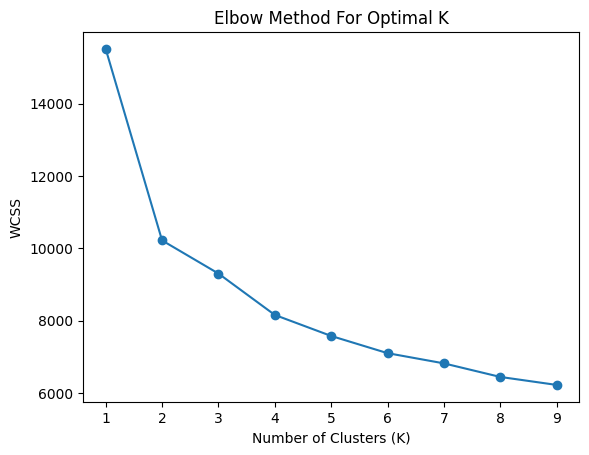

In [137]:
plt.plot(range(1, 10), wcss, marker="o")
plt.title("Elbow Method For Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [150]:
kmeans = KMeans(n_clusters=6, random_state=42)

# 2. Fit and assign new cluster labels (0 to 5)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 3. Recalculate summary table
cluster_summary = df.groupby('cluster')[['Age', 'Income', 'Total_spending', 'NumWebPurchases', 'NumStorePurchases']].mean()
cluster_summary

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases
cluster,,,,,
0,49.758850,32837.701327,114.064159,2.157080,3.243363
1,47.089820,75444.853293,1307.272455,4.763473,8.799401
2,50.092643,32783.937330,116.757493,2.343324,3.196185
3,60.727907,59554.174419,884.241860,7.858140,7.925581
4,69.977778,77107.879365,1205.717460,4.536508,8.225397
5,69.028302,43426.745283,170.496855,2.575472,4.018868


In [151]:
df['cluster']

,cluster
0,3
1,5
2,3
3,0
4,2
...,...
2235,3
2236,3
2237,1
2238,4


In [152]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_spending,Customer_Since,AcceptedAny,AgeGroup,cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,69,0,1617,5098,1,60-69,3
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,72,2,27,4548,0,70+,5
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,61,0,776,4747,0,60-69,3
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,42,1,53,4574,0,40-49,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,45,1,422,4596,0,40-49,2


In [153]:
cluster_summary = df.groupby("cluster")[features].mean()

In [154]:
cluster_summary

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
cluster,,,,,,,
0,49.758850,32837.701327,114.064159,2.157080,3.243363,6.652655,24.429204
1,47.089820,75444.853293,1307.272455,4.763473,8.799401,2.790419,48.685629
2,50.092643,32783.937330,116.757493,2.343324,3.196185,7.065395,77.005450
3,60.727907,59554.174419,884.241860,7.858140,7.925581,6.397674,46.097674
4,69.977778,77107.879365,1205.717460,4.536508,8.225397,2.526984,52.885714
5,69.028302,43426.745283,170.496855,2.575472,4.018868,5.371069,52.097484


In [156]:
df['cluster'].value_counts()

,count
cluster,
0,452
3,430
2,367
1,334
5,318
4,315


In [159]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"],df["PCA2"]=pca_data[:,0], pca_data[:,1]

In [160]:
pca_data

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]])

<Axes: xlabel='PCA1', ylabel='PCA2'>

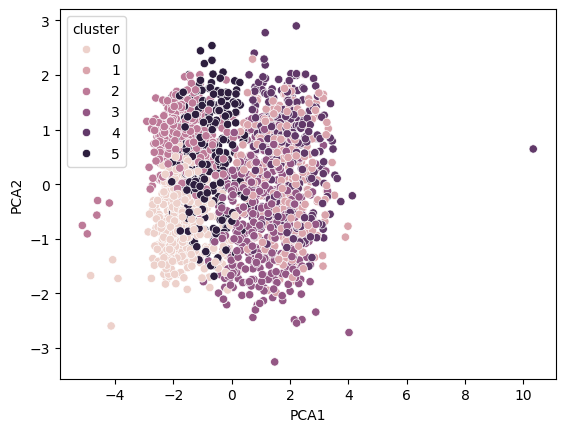

In [161]:
sns.scatterplot(x="PCA1",y='PCA2',hue='cluster',data =df)

In [162]:
cluster_summary

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
cluster,,,,,,,
0,49.758850,32837.701327,114.064159,2.157080,3.243363,6.652655,24.429204
1,47.089820,75444.853293,1307.272455,4.763473,8.799401,2.790419,48.685629
2,50.092643,32783.937330,116.757493,2.343324,3.196185,7.065395,77.005450
3,60.727907,59554.174419,884.241860,7.858140,7.925581,6.397674,46.097674
4,69.977778,77107.879365,1205.717460,4.536508,8.225397,2.526984,52.885714
5,69.028302,43426.745283,170.496855,2.575472,4.018868,5.371069,52.097484


In [163]:
import joblib
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']